# 🔍 EDA — Iris Dataset

Análisis exploratorio de datos del dataset Iris.
Objetivo: entender las distribuciones, correlaciones y separabilidad de las clases.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Carga de datos

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "target"]
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

print(f"Shape: {df.shape}")
df.head()

Shape: (150, 6)


,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. Estadísticas descriptivas

In [3]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Balance de clases
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 3. Distribución de features por especie

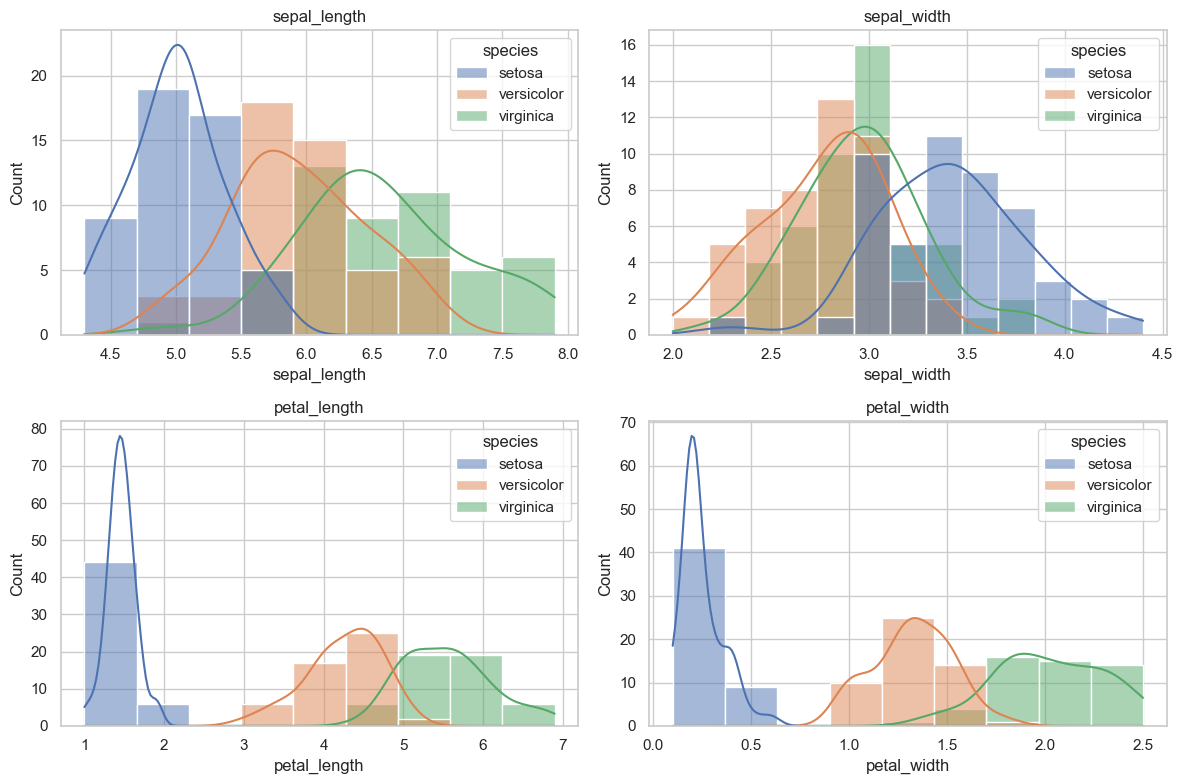

In [5]:
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flat, features):
    sns.histplot(data=df, x=feat, hue="species", kde=True, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

## 4. Boxplots

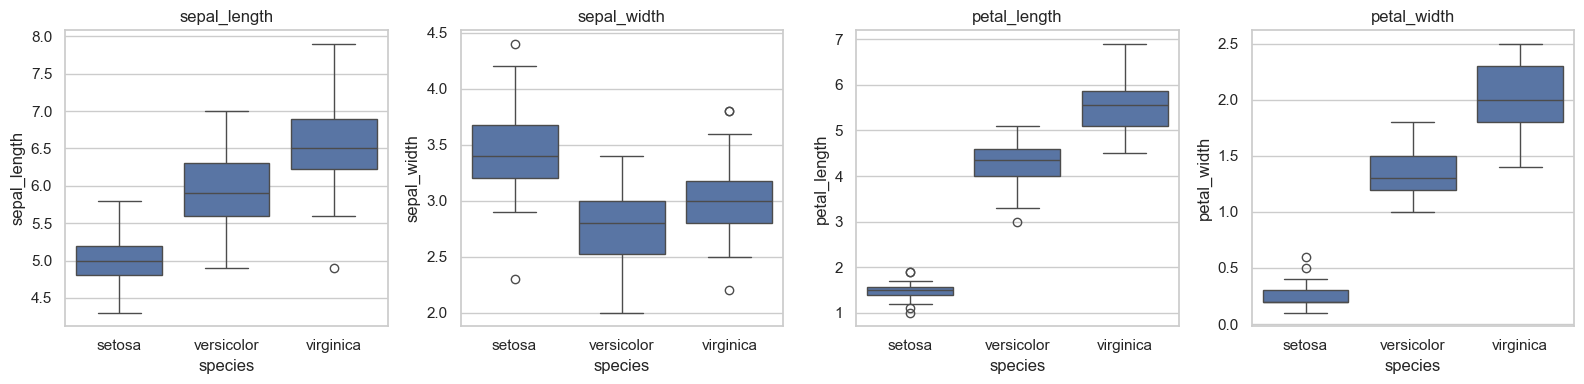

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, features):
    sns.boxplot(data=df, x="species", y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

## 5. Matriz de correlación

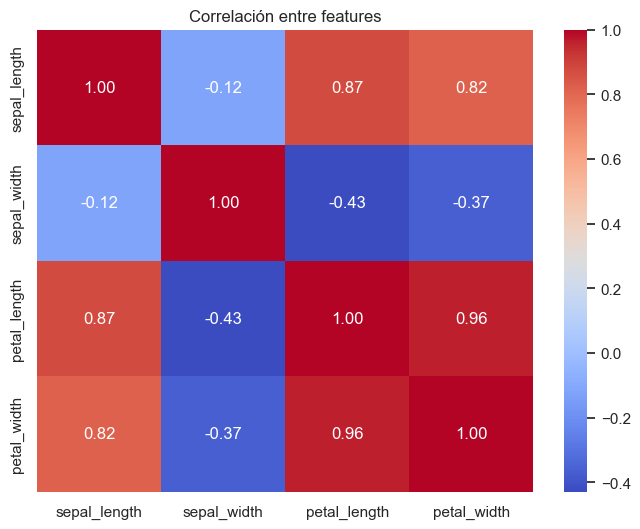

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre features")
plt.show()

## 6. Pairplot (separabilidad visual)

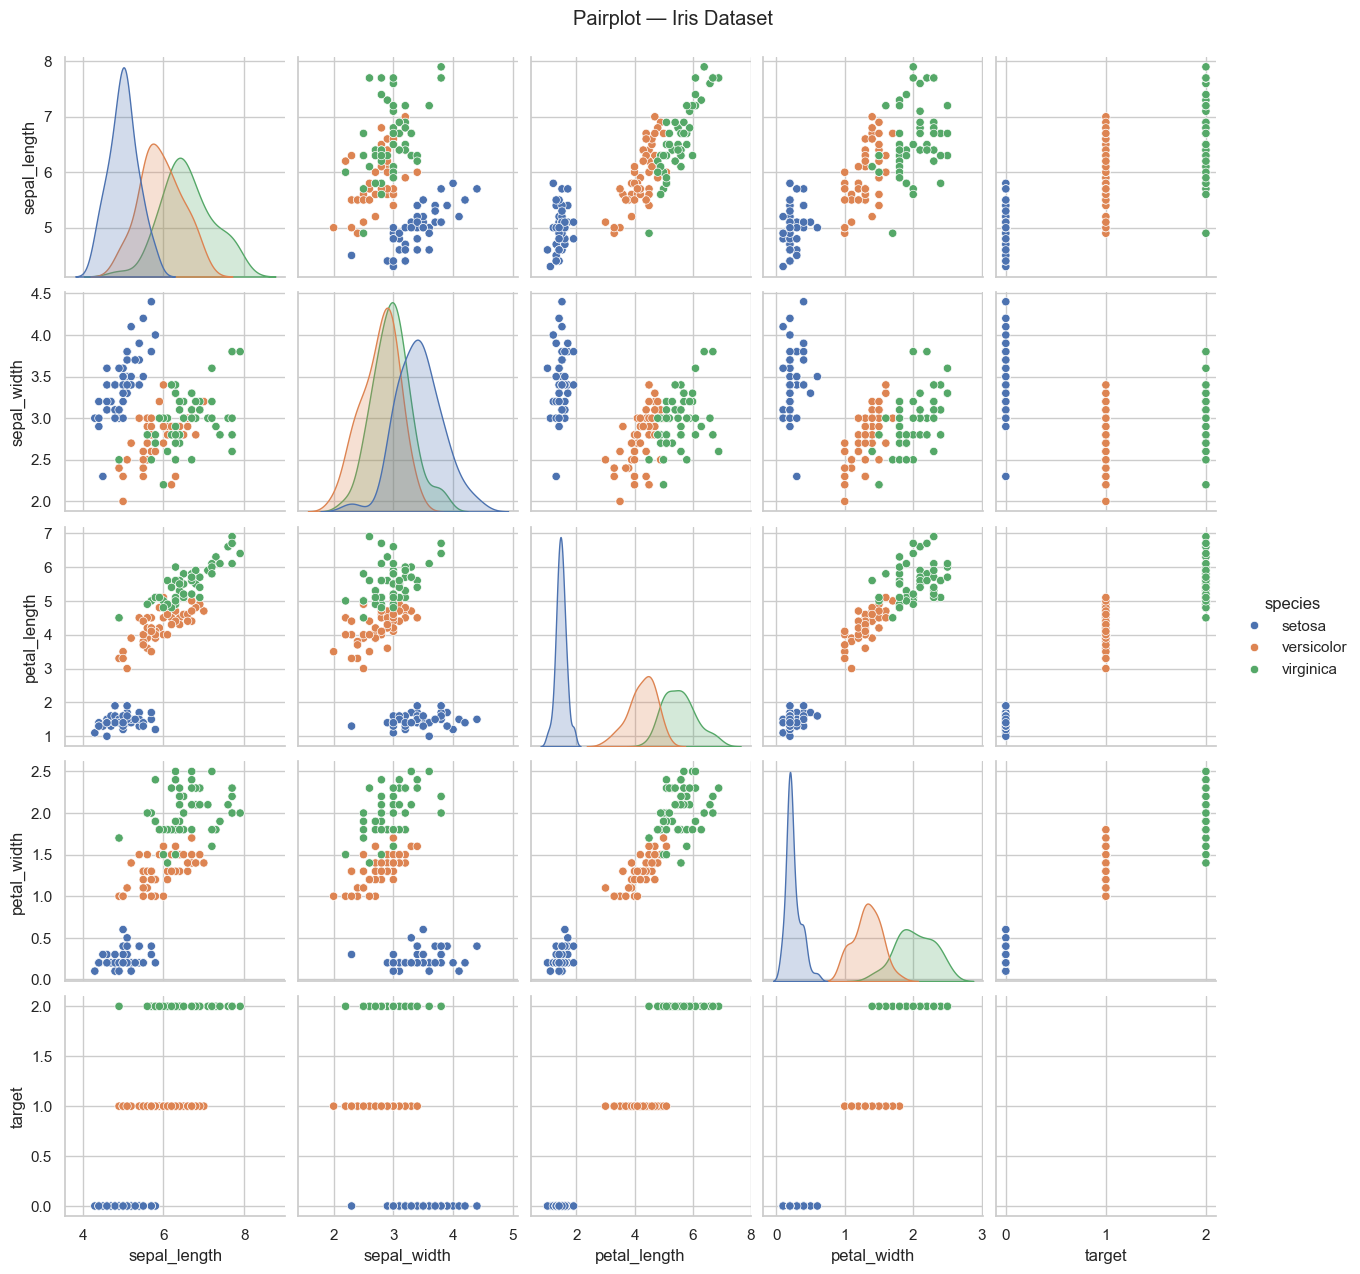

In [8]:
sns.pairplot(df, hue="species", diag_kind="kde")
plt.suptitle("Pairplot — Iris Dataset", y=1.02)
plt.show()

## 7. Conclusiones del EDA

- **Dataset balanceado**: 50 muestras por clase.
- **Setosa claramente separable**: `petal_length` y `petal_width` la distinguen perfectamente.
- **Versicolor vs Virginica**: mayor solapamiento, especialmente en features de sépalo.
- **Alta correlación**: `petal_length` ↔ `petal_width` (~0.96).
- **Sin valores nulos ni outliers extremos**.